In [1]:
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn

from graph_builder import assemble_graph
from models.outfit_gnn import OutfitGNNModel
from train import train_loop

from features.image_features import ImageEncoder, extract_image_feature, IMAGE_EMBED_DIM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGES_ROOT = Path("C:/Users/shrey/OneDrive/Desktop/Outfit-recommendation/dataset/images")

In [2]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

path = "..\\sample_data\\polyvore\\test_no_dup.json"   # (your dataset)
data = load_json(path)

print("Loaded outfits:", len(data))


Loaded outfits: 3076


In [3]:
def extract_items_and_image_features(global_data, image_model):
    node_map = {}
    outfits = []
    feats = []
    current_id = 0

    for outfit in global_data:
        set_id = str(outfit["set_id"])
        outfit_ids = []

        for it in outfit["items"]:
            key = (set_id, it["index"])
            if key not in node_map:
                node_map[key] = current_id
                
                img_path = IMAGES_ROOT / set_id / f"{it['index']}.jpg"
                if not img_path.exists():
                    raise FileNotFoundError(f"Missing: {img_path}")

                emb = extract_image_feature(img_path, image_model)
                feats.append(emb.astype(np.float32))

                current_id += 1

            outfit_ids.append(node_map[key])
        outfits.append(outfit_ids)

    feats = np.vstack(feats)
    node_attrs = [{} for _ in range(len(feats))]

    return node_attrs, outfits, feats


In [4]:
print("Loading ResNet50 Image Encoder...")
image_model = ImageEncoder().to(device)

print("Extracting item image features...")
node_attrs, outfits, feat_matrix = extract_items_and_image_features(data, image_model)

num_nodes = feat_matrix.shape[0]
print("Total nodes:", num_nodes)
print("Total outfits:", len(outfits))


Loading ResNet50 Image Encoder...
Extracting item image features...
Total nodes: 18604
Total outfits: 3076


In [5]:
print("Building graph...")

graph = assemble_graph(
    num_nodes=num_nodes,
    emb_matrix=feat_matrix,
    outfits=outfits,
    node_attrs=node_attrs,
    strategies=["knn", "cooccurrence"],  # can add: "attr:category"
    knn_k=5,
)

edge_index = torch.tensor(graph["edge_index"], dtype=torch.long)

node_features = torch.tensor(feat_matrix, dtype=torch.float32)

print("Graph edges:", edge_index.shape[1])


Building graph...
Graph edges: 192483


In [6]:
in_dim = node_features.shape[1]  # should be 512 from image features
model = OutfitGNNModel(in_dim=in_dim, hidden_dims=[256,256], out_dim=128)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

trained_model, history = train_loop(
    model=model,
    node_features=node_features,
    edge_index=edge_index,
    outfits=outfits,
    optimizer=optimizer,
    device=device,
    epochs=100,
    batch_size=64,
    loss_type="margin",
    margin=0.2,
    checkpoint_dir="./checkpoints_all"
)

print("Training complete!")


Epoch 1/100 loss=0.0391 recall@10=0.2450


KeyboardInterrupt: 

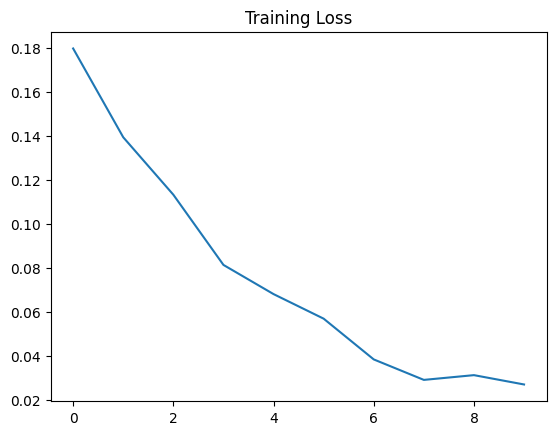

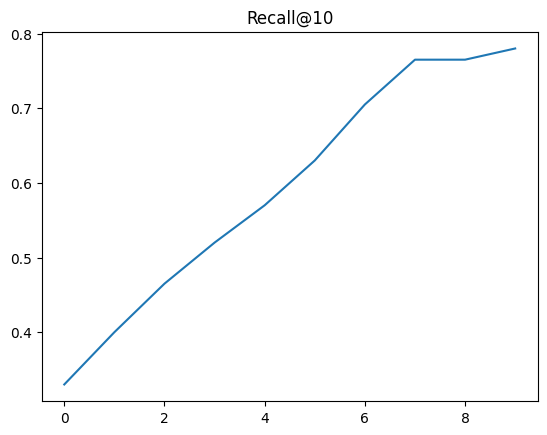

In [10]:
import matplotlib.pyplot as plt

plt.plot(history["loss"])
plt.title("Training Loss")
plt.show()

plt.plot(history["recall@10"])
plt.title("Recall@10")
plt.show()


In [84]:
model1 = OutfitGNNModel(
    in_dim=512,
    hidden_dims=[256,256],
    out_dim=128
).to(device)

model1.load_state_dict(torch.load('./checkpoints/model_epoch_10.pt', map_location='cpu'))


<All keys matched successfully>

In [85]:
def predict_compatibility_from_images(img1_path, img2_path, gnn_model):
    import torch
    from pathlib import Path
    from features.image_features import ImageEncoder, extract_image_feature

    device = torch.device("cpu")

    # 1. Image Encoder on CPU
    image_model = ImageEncoder().to(device)
    gnn_model = gnn_model.to(device)
    gnn_model.eval()

    # 2. Extract 512D image embeddings
    feat1 = extract_image_feature(Path(img1_path), image_model, device=device)
    feat2 = extract_image_feature(Path(img2_path), image_model, device=device)

    feat1 = torch.tensor(feat1, dtype=torch.float32).unsqueeze(0)   # (1,512)
    feat2 = torch.tensor(feat2, dtype=torch.float32).unsqueeze(0)   # (1,512)

    # 3. Create dummy graph: 1 node, no edges
    edge_index = torch.zeros((2,0), dtype=torch.long)

    # 4. Pass THROUGH the full GNN encoder (conv layers + project)
    with torch.no_grad():
        z1 = gnn_model.encoder(feat1, edge_index)   # (1,128)
        z2 = gnn_model.encoder(feat2, edge_index)   # (1,128)

        score = gnn_model.scorer(z1, z2)

    print("Compatibility Score:", float(score.item()))
    return float(score.item())


In [101]:
score = predict_compatibility_from_images(
    f"{IMAGES_ROOT}/214181831/1.jpg",
    f"{IMAGES_ROOT}/4035878/2.jpg",
    model1
)

Compatibility Score: 0.04948366433382034


In [7]:
feat_matrix.shape

(18604, 512)

In [8]:
feat_matrix.size

9525248

In [11]:
18604*512*8/1024/1024

72.671875